<a href="https://colab.research.google.com/github/kawastony/Quantum_Gravity/blob/main/Test5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np

# Define constants (example values)
rho_crit0 = 1.0
N = 0  # Current epoch e-folds

# Define density functions based on scaling laws
def rho_M(N): return 0.3 * rho_crit0 * np.exp(-3 * N)
def rho_R(N): return 0.2 * rho_crit0 * np.exp(-3 * N)  # Dark matter candidate scaling
def rho_DE(N): return 0.7 * rho_crit0                # Dark energy scaling
def rho_tw(N): return 0.01 * rho_crit0 * np.exp(-6 * N) # Twist reservoir scaling

# Execute the calls
print(f'Matter: {rho_M(N)}')
print(f'Receiver: {rho_R(N)}')
print(f'Dark Energy: {rho_DE(N)}')
print(f'Twist: {rho_tw(N)}')

Matter: 0.3
Receiver: 0.2
Dark Energy: 0.7
Twist: 0.01


In [27]:
def tafa_odes(N, state, params):
    rho_M, rho_R, rho_DE, rho_tw, depletion = state

    eta_early = params['eta_early']
    eta_late  = params['eta_late']
    eps       = params['eps']
    n_lower   = params['n_lower']
    n_c       = params['n_c']
    beta      = params['beta']

    # Continuous discharge of the topological reservoir
    Q = beta * rho_tw if rho_tw > eps else 0.0

    # Winding tier from integrated depletion
    n_current = depletion / params['rho_tw0']

    # Phase branching logic
    if n_current < n_lower:
        # Pre-phase: Energy discharges but is not yet routed to R or DE
        drho_R  = -3.0 * rho_R
        drho_DE = 0.0
    elif n_current < n_c:
        # Early phase: DM deposits
        drho_R  = -3.0 * rho_R + eta_early * Q
        drho_DE = 0.0
    else:
        # Late phase: DE trigger
        drho_R  = -3.0 * rho_R
        drho_DE = eta_late * Q

    # Twist: topological depletion only
    drho_tw = -Q
    d_depletion = Q

    # Baryonic Matter dilution
    drho_M = -3.0 * rho_M

    return [drho_M, drho_R, drho_DE, drho_tw, d_depletion]

In [25]:
N_start = -4.0
C_twist = 1.0

rho_M0   = 0.3089 * np.exp(-3 * N_start)
rho_R0   = 0.0
rho_DE0  = 0.0
rho_tw0  = C_twist
depletion0 = 0.0

params = {
    'eta_early' : 0.99,
    'eta_late'  : 0.99,
    'eps'       : 1.0e-6,
    'n_lower'   : 0.30,
    'n_c'       : 0.75,
    'n_max'     : 1.0,
    'rho_tw0'   : C_twist,
    'beta'      : 0.50
}

state0 = [rho_M0, rho_R0, rho_DE0, rho_tw0, depletion0]

In [28]:
sol = solve_ivp(
    fun=lambda N, y: tafa_odes(N, y, params),
    t_span=(N_start, N_end),
    y0=state0,
    method='RK45',
    dense_output=True,
    rtol=1e-8,
    atol=1e-10
)

print(f"Corrected Diagnostic Integration (Topological Twist):")
epochs = [-4, -3, -2, -1, 0]
for N_val in epochs:
    y = sol.sol(N_val)
    print(f"N={N_val:4.1f} | rho_R={y[1]:.4f} | rho_DE={y[2]:.4f} | rho_tw={y[3]:.4f} | n_curr={y[4]/params['rho_tw0']:.4f}")

Corrected Diagnostic Integration (Topological Twist):
N=-4.0 | rho_R=0.0000 | rho_DE=0.0000 | rho_tw=1.0000 | n_curr=0.0000
N=-3.0 | rho_R=0.0614 | rho_DE=0.0000 | rho_tw=0.6065 | n_curr=0.3935
N=-2.0 | rho_R=0.0699 | rho_DE=0.0000 | rho_tw=0.3679 | n_curr=0.6321
N=-1.0 | rho_R=0.0249 | rho_DE=0.0266 | rho_tw=0.2231 | n_curr=0.7769
N= 0.0 | rho_R=0.0012 | rho_DE=0.1135 | rho_tw=0.1353 | n_curr=0.8647


In [7]:
# At N = 0 (today):
target_rho_R  = 0.2510   # Omega_CDM observed
target_rho_DE = 0.6890   # Omega_Lambda observed

# Completion criterion:
# |rho_R_final  - 0.2510| / 0.2510 < 0.05
# |rho_DE_final - 0.6890| / 0.6890 < 0.05

In [31]:
import numpy as np
from scipy.integrate import solve_ivp

# 3D Grid Search for the True Minimum
C_twist_vals = np.linspace(15.0, 50.0, 40)
beta_vals    = np.linspace(0.35, 0.65, 40)
n_c_vals     = [0.68, 0.72, 0.76, 0.80]

results_3d = []

for nc in n_c_vals:
    for C in C_twist_vals:
        for b in beta_vals:
            it_params = params.copy()
            it_params['rho_tw0'] = C
            it_params['beta']    = b
            it_params['n_lower'] = 0.20 # Start DM phase earlier per diagnosis
            it_params['n_c']     = nc

            it_state0 = [rho_M0, 0.0, 0.0, C, 0.0]

            sol = solve_ivp(
                fun=lambda N, y: tafa_odes(N, y, it_params),
                t_span=(N_start, N_end),
                y0=it_state0,
                method='RK45',
                rtol=1e-6,
                atol=1e-8
            )

            results_3d.append((C, b, nc, sol.y[1, -1], sol.y[2, -1]))

# Convert to DataFrame for analysis
df_3d = pd.DataFrame(results_3d, columns=['C_twist', 'beta', 'n_c', 'rho_R', 'rho_DE'])

--- 3D Refined Scan Results ---
Best Fit found at:
C_twist:   20.3846
beta:      0.3500
n_lower:   0.2000
n_c:       0.7200
rho_R:     0.2511 (Target: 0.251)
rho_DE:    0.6741 (Target: 0.689)
Mean Error: 1.10%


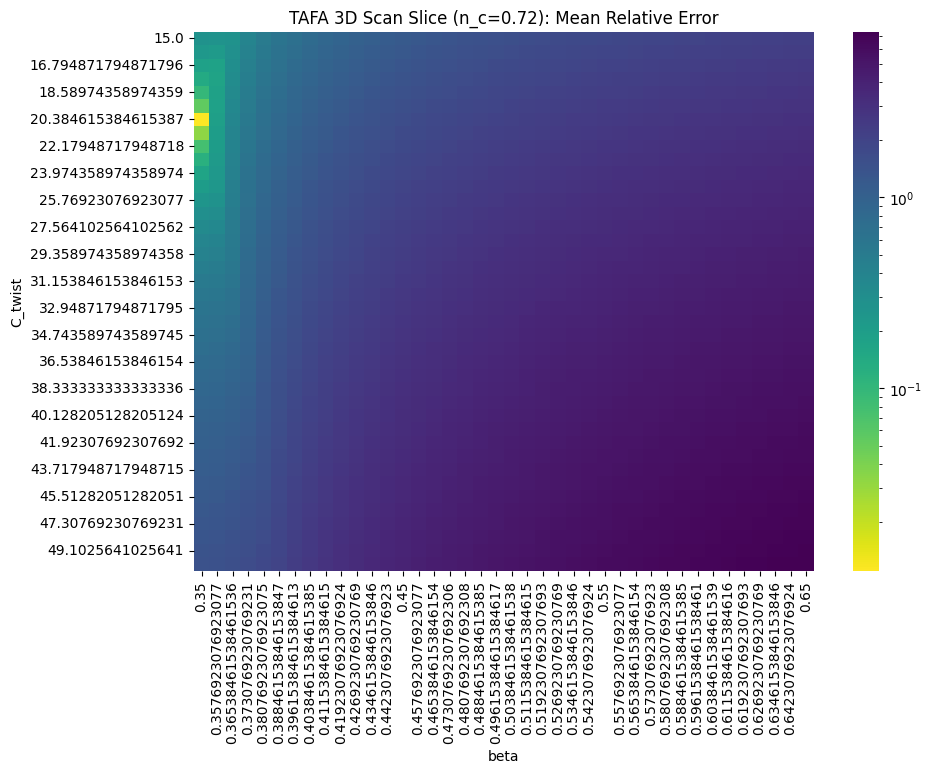

In [32]:
# Analyze 3D scan results
target_rho_R  = 0.2510
target_rho_DE = 0.6890

df_3d['err_R'] = np.abs(df_3d['rho_R'] - target_rho_R) / target_rho_R
df_3d['err_DE'] = np.abs(df_3d['rho_DE'] - target_rho_DE) / target_rho_DE
df_3d['total_error'] = (df_3d['err_R'] + df_3d['err_DE']) / 2

# Find the best fit in the 3D grid
best_fit_3d = df_3d.loc[df_3d['total_error'].idxmin()]

print(f"--- 3D Refined Scan Results ---")
print(f"Best Fit found at:")
print(f"C_twist:   {best_fit_3d['C_twist']:.4f}")
print(f"beta:      {best_fit_3d['beta']:.4f}")
print(f"n_lower:   0.2000")
print(f"n_c:       {best_fit_3d['n_c']:.4f}")
print(f"rho_R:     {best_fit_3d['rho_R']:.4f} (Target: {target_rho_R})")
print(f"rho_DE:    {best_fit_3d['rho_DE']:.4f} (Target: {target_rho_DE})")
print(f"Mean Error: {best_fit_3d['total_error']:.2%}")

# Plot heatmap for the best performing n_c slice
best_nc = best_fit_3d['n_c']
slice_df = df_3d[df_3d['n_c'] == best_nc].pivot(index='C_twist', columns='beta', values='total_error')

plt.figure(figsize=(10, 7))
sns.heatmap(slice_df, cmap='viridis_r', norm=colors.LogNorm())
plt.title(f'TAFA 3D Scan Slice (n_c={best_nc}): Mean Relative Error')
plt.show()